In [7]:
#!/usr/bin/env python3
"""
EDA DAGMA — Ground Truth Cali (>=10 visualizaciones)
====================================================
Variables objetivo: NO2, SO2, O3
Datos meteorológicos: VViento, DViento, P, TAire10
"""

import json, glob, gc
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

ROOT     = Path().resolve().parent.parent          # ← era .parent.parent.parent
DATA_DIR = ROOT / "data" / "dagma" / "raw"
OUT_DIR  = ROOT / "outputs" / "eda" / "dagma"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = ["NO2", "SO2", "O3"]
METEOR  = ["VViento", "DViento"]
DPI     = 150

print(f"ROOT     : {ROOT}")
print(f"DATA_DIR : {DATA_DIR}  →  existe: {DATA_DIR.exists()}")
print(f"OUT_DIR  : {OUT_DIR}")


ROOT     : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality
DATA_DIR : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/data/dagma/raw  →  existe: True
OUT_DIR  : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/dagma


In [8]:
def load():
    """Carga eficiente: solo columnas necesarias, chunks de 50k."""
    files = sorted(DATA_DIR.glob("g4t8_*.csv"))
    
    # ── Diagnóstico temprano ──────────────────────────────────────────
    if not files:
        raise FileNotFoundError(
            f"No se encontraron archivos g4t8_*.csv en:\n  {DATA_DIR}\n"
            f"  ¿Existe el directorio? {DATA_DIR.exists()}"
        )
    print(f"  Archivos encontrados: {len(files)}")
    for f in files:
        print(f"    · {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

    cols = ["nombre_est", "nombre_fgda", "msfl_code",
            "med_concentracion_estandar", "med_fecha_inicio",
            "latitud", "longitud"]
    chunks = []
    rows_raw = 0

    for f in files:
        for chunk in pd.read_csv(
            f, usecols=cols, chunksize=50_000,
            encoding="utf-8", on_bad_lines="skip"
        ):
            rows_raw += len(chunk)
            chunk["fecha"] = pd.to_datetime(chunk["med_fecha_inicio"], errors="coerce")
            chunk["valor"] = pd.to_numeric(chunk["med_concentracion_estandar"], errors="coerce")
            chunk = chunk.dropna(subset=["fecha", "valor"])
            if len(chunk):
                chunks.append(
                    chunk[["nombre_est","nombre_fgda","msfl_code",
                           "valor","fecha","latitud","longitud"]]
                )

    print(f"  Filas leídas (raw): {rows_raw:,}")
    print(f"  Chunks con datos válidos: {len(chunks)}")

    # ── Guardia: lista vacía ──────────────────────────────────────────
    if not chunks:
        raise ValueError(
            "Todos los chunks quedaron vacíos tras dropna.\n"
            "Posibles causas:\n"
            "  1. Las columnas 'med_fecha_inicio' o 'med_concentracion_estandar' "
            "tienen otro nombre en tus CSVs.\n"
            "  2. Los archivos existen pero están vacíos o mal formateados.\n"
            f"  → Columnas reales del primer archivo: "
            f"{list(pd.read_csv(files[0], nrows=0).columns)}"
        )

    df = pd.concat(chunks, ignore_index=True)
    df["hora"]    = df["fecha"].dt.hour
    df["mes"]     = df["fecha"].dt.month
    df["ano"]     = df["fecha"].dt.year
    df["dia_sem"] = df["fecha"].dt.dayofweek
    return df

print("Cargando DAGMA (3.8M registros)...")
df = load()
print(f"  → {len(df):,} registros, {df['nombre_est'].nunique()} estaciones, "
      f"{df['msfl_code'].nunique()} variables")
print(f"  Periodo: {df['fecha'].min()} → {df['fecha'].max()}")

Cargando DAGMA (3.8M registros)...
  Archivos encontrados: 79
    · g4t8_2020_000.csv  (10.9 MB)
    · g4t8_2020_001.csv  (10.9 MB)
    · g4t8_2020_002.csv  (10.8 MB)
    · g4t8_2020_003.csv  (10.8 MB)
    · g4t8_2020_004.csv  (10.8 MB)
    · g4t8_2020_005.csv  (10.8 MB)
    · g4t8_2020_006.csv  (10.7 MB)
    · g4t8_2020_007.csv  (10.8 MB)
    · g4t8_2020_008.csv  (10.8 MB)
    · g4t8_2020_009.csv  (10.8 MB)
    · g4t8_2020_010.csv  (10.8 MB)
    · g4t8_2020_011.csv  (10.7 MB)
    · g4t8_2020_012.csv  (10.7 MB)
    · g4t8_2020_013.csv  (5.1 MB)
    · g4t8_2021_000.csv  (10.7 MB)
    · g4t8_2021_001.csv  (10.6 MB)
    · g4t8_2021_002.csv  (10.6 MB)
    · g4t8_2021_003.csv  (10.6 MB)
    · g4t8_2021_004.csv  (10.6 MB)
    · g4t8_2021_005.csv  (10.5 MB)
    · g4t8_2021_006.csv  (10.7 MB)
    · g4t8_2021_007.csv  (10.7 MB)
    · g4t8_2021_008.csv  (10.7 MB)
    · g4t8_2021_009.csv  (10.7 MB)
    · g4t8_2021_010.csv  (10.7 MB)
    · g4t8_2021_011.csv  (10.6 MB)
    · g4t8_2021_012.csv  (3.6

In [9]:
# Subsets reutilizables a lo largo del notebook
df_no2 = df[df["msfl_code"] == "NO2"].copy()
df_so2 = df[df["msfl_code"] == "SO2"].copy()
df_o3  = df[df["msfl_code"] == "O3"].copy()

print(f"NO2 → {len(df_no2):,} registros")
print(f"SO2 → {len(df_so2):,} registros")
print(f"O3  → {len(df_o3):,} registros")

NO2 → 25,377 registros
SO2 → 79,900 registros
O3  → 142,380 registros


## Fig 1 · Registros por estación

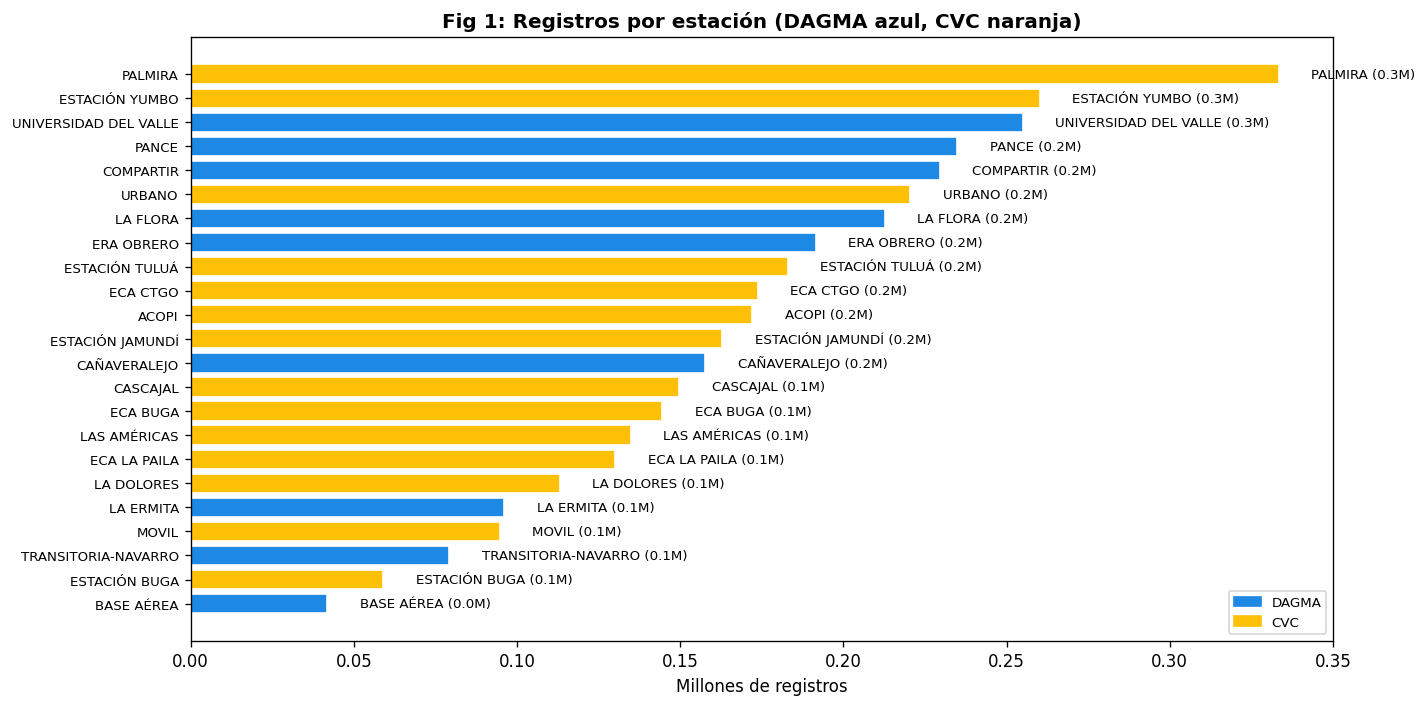

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

cnt    = df.groupby(["nombre_est", "nombre_fgda"]).size().sort_values()
colors = ["#1E88E5" if r[1] == "DAGMA" else "#FFC107" for r in cnt.index]

ax.barh(range(len(cnt)), cnt.values / 1e6, color=colors, edgecolor="white")
for i, (v, (n, g)) in enumerate(zip(cnt.values, cnt.index)):
    ax.text(v / 1e6 + 0.01, i, f"{n} ({v/1e6:.1f}M)", va="center", fontsize=8)

ax.set_yticks(range(len(cnt)))
ax.set_yticklabels([n for n, _ in cnt.index], fontsize=8)
ax.set_xlabel("Millones de registros")
ax.set_title("Fig 1: Registros por estación (DAGMA azul, CVC naranja)", fontweight="bold")
ax.legend(
    handles=[Patch(color="#1E88E5", label="DAGMA"), Patch(color="#FFC107", label="CVC")],
    fontsize=8
)

plt.tight_layout()
plt.savefig(OUT_DIR / "01_registros_por_estacion.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## Fig 2 · Distribución de variables medidas

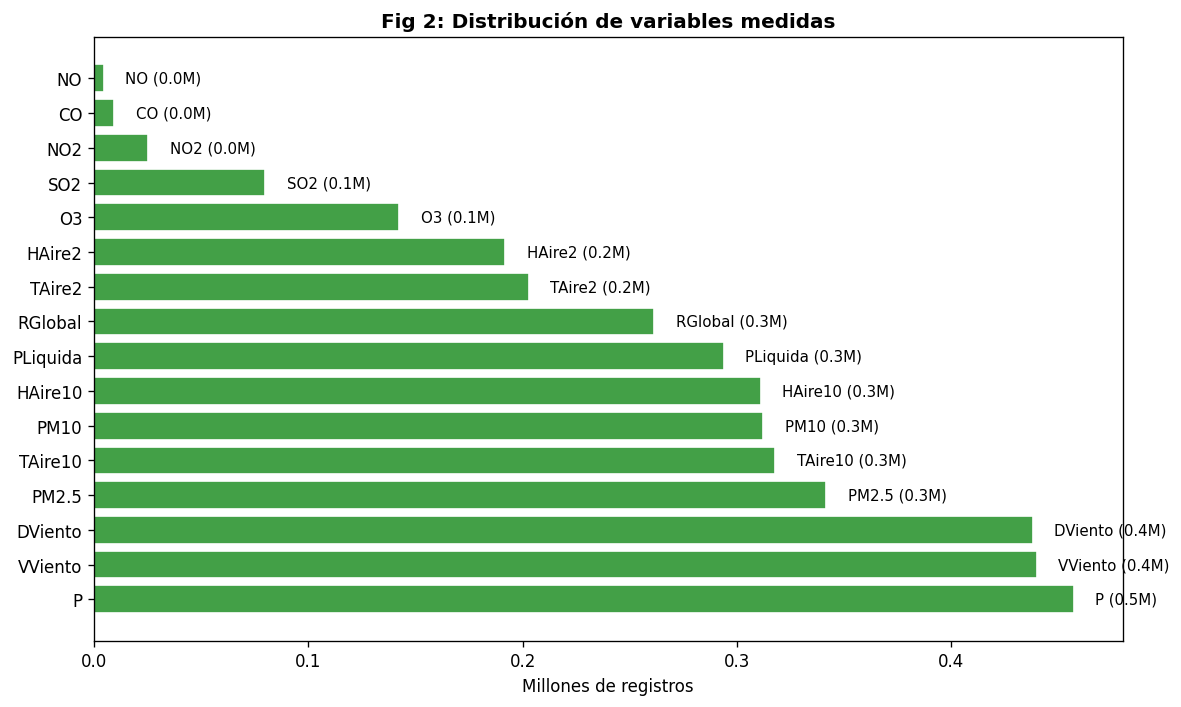

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

vc = df["msfl_code"].value_counts()
ax.barh(range(len(vc)), vc.values / 1e6, color="#43A047", edgecolor="white")
for i, (v, c) in enumerate(zip(vc.index, vc.values)):
    ax.text(c / 1e6 + 0.01, i, f"{v} ({c/1e6:.1f}M)", va="center", fontsize=9)

ax.set_yticks(range(len(vc)))
ax.set_yticklabels(vc.index)
ax.set_xlabel("Millones de registros")
ax.set_title("Fig 2: Distribución de variables medidas", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR / "02_variables_medidas.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## Fig 3 · Heatmap registros × mes × estación (top 10)

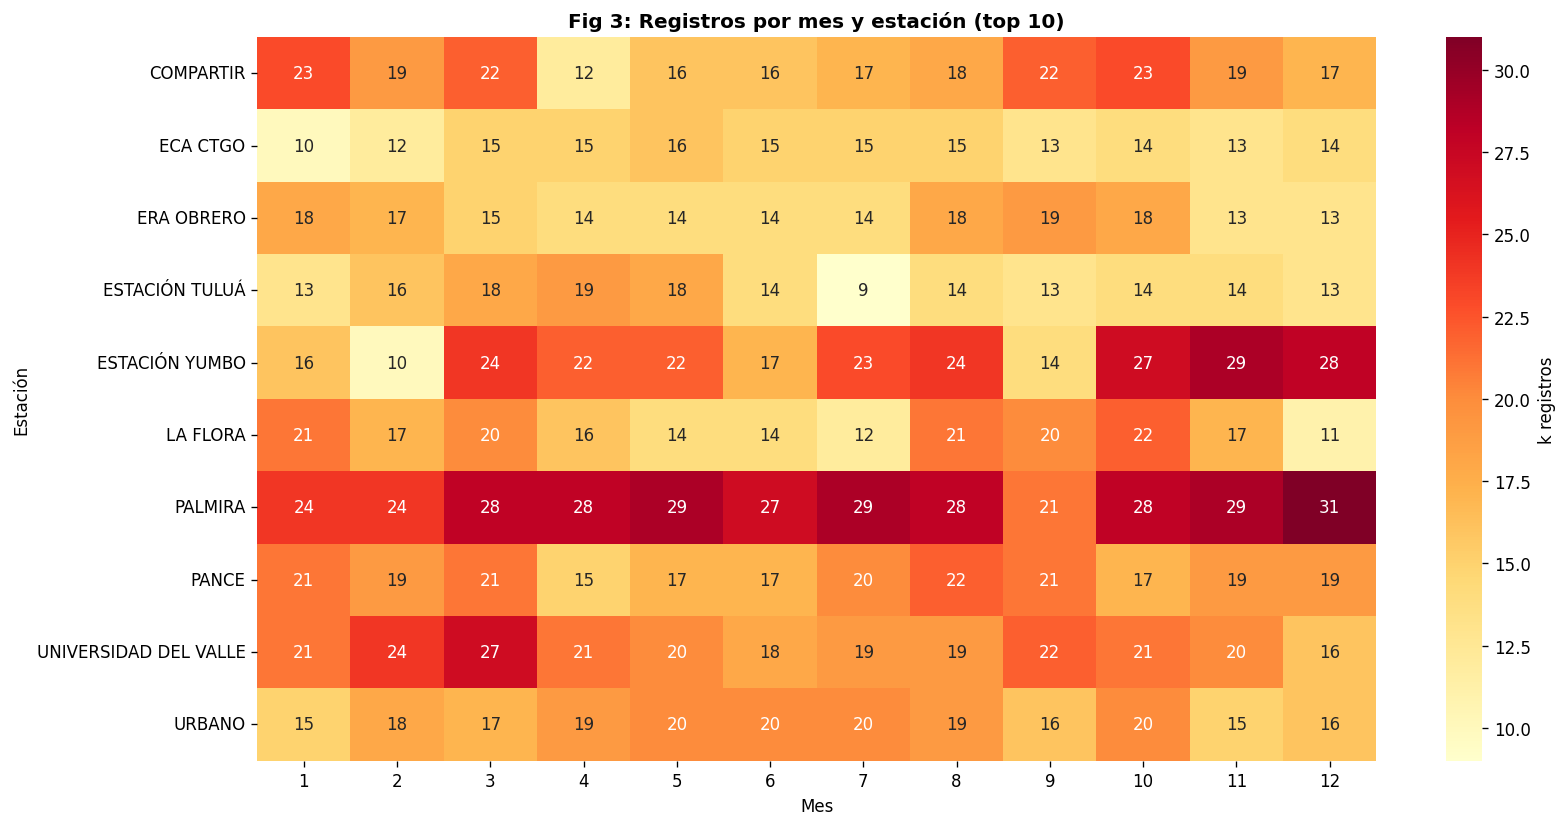

In [12]:
top_stations = df.groupby("nombre_est").size().nlargest(10).index
df_sub = df[df["nombre_est"].isin(top_stations)]
hm = df_sub.groupby(["nombre_est", "mes"]).size().unstack(fill_value=0)
hm = hm.div(1e3).astype(int)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(hm, annot=True, fmt="d", cmap="YlOrRd",
            cbar_kws={"label": "k registros"}, ax=ax)
ax.set_title("Fig 3: Registros por mes y estación (top 10)", fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Estación")

plt.tight_layout()
plt.savefig(OUT_DIR / "03_heatmap_estacion_mes.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## Fig 4 · Series temporales NO₂ (diario por estación)

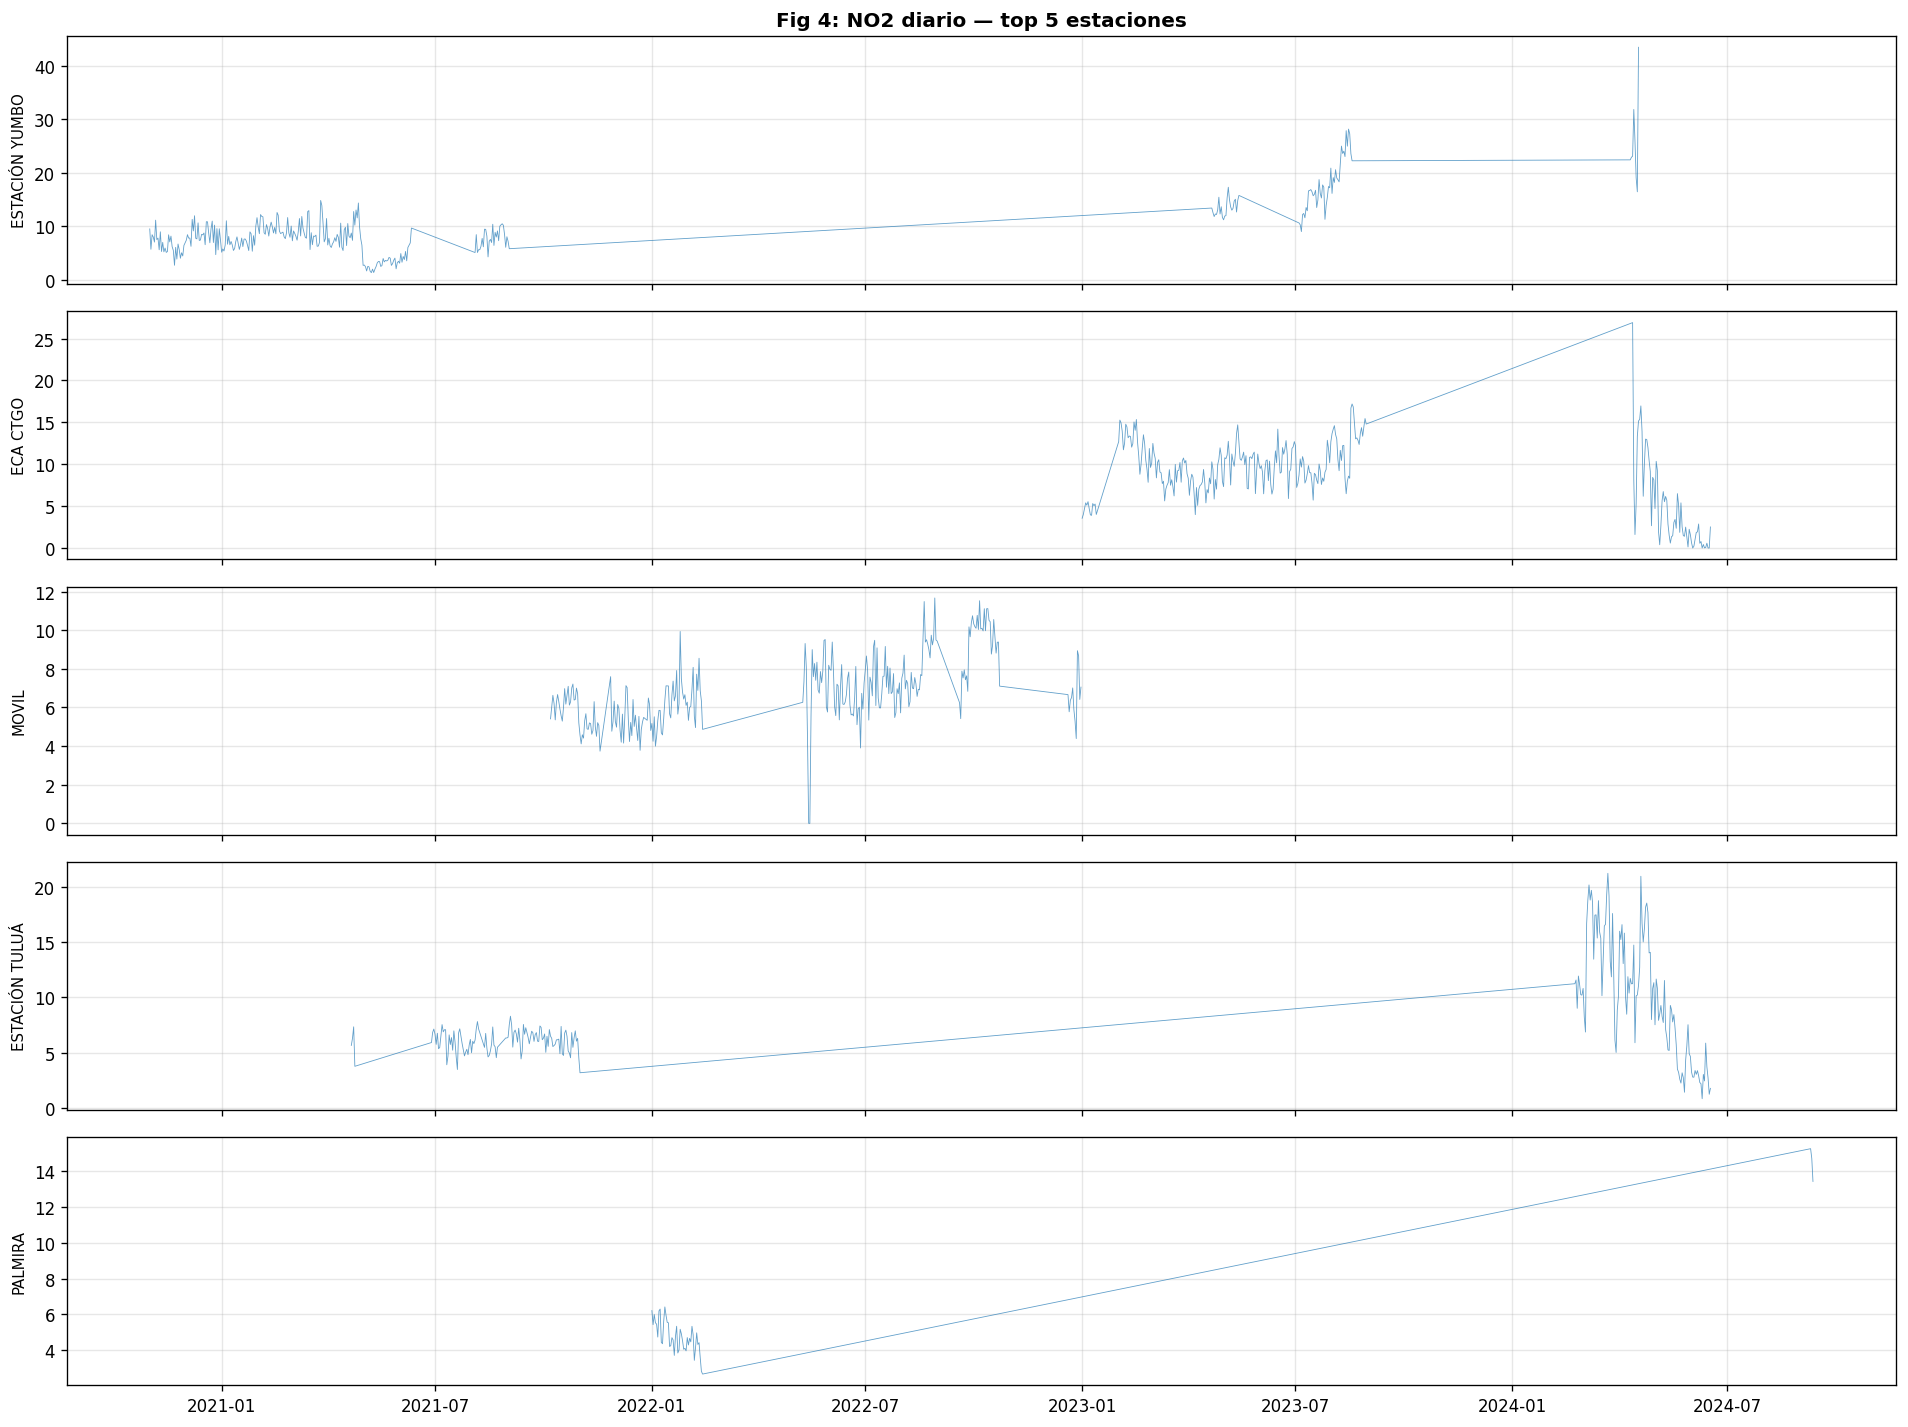

27257

In [13]:
if len(df_no2) > 1_000:
    df_no2["fecha_dia"] = df_no2["fecha"].dt.date
    ts_no2 = df_no2.groupby(["nombre_est", "fecha_dia"])["valor"].mean().reset_index()
    top5   = ts_no2.groupby("nombre_est").size().nlargest(5).index

    fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
    for ax, st in zip(axes, top5):
        d = ts_no2[ts_no2["nombre_est"] == st]
        ax.plot(pd.to_datetime(d["fecha_dia"]), d["valor"], lw=0.5, alpha=0.7)
        ax.set_ylabel(st, fontsize=9)
        ax.grid(alpha=0.3)
    axes[0].set_title("Fig 4: NO2 diario — top 5 estaciones", fontweight="bold")

    fig.tight_layout()
    plt.savefig(OUT_DIR / "04_no2_series_temporales.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()

gc.collect()

## Fig 5 · Series temporales SO₂ (diario por estación)

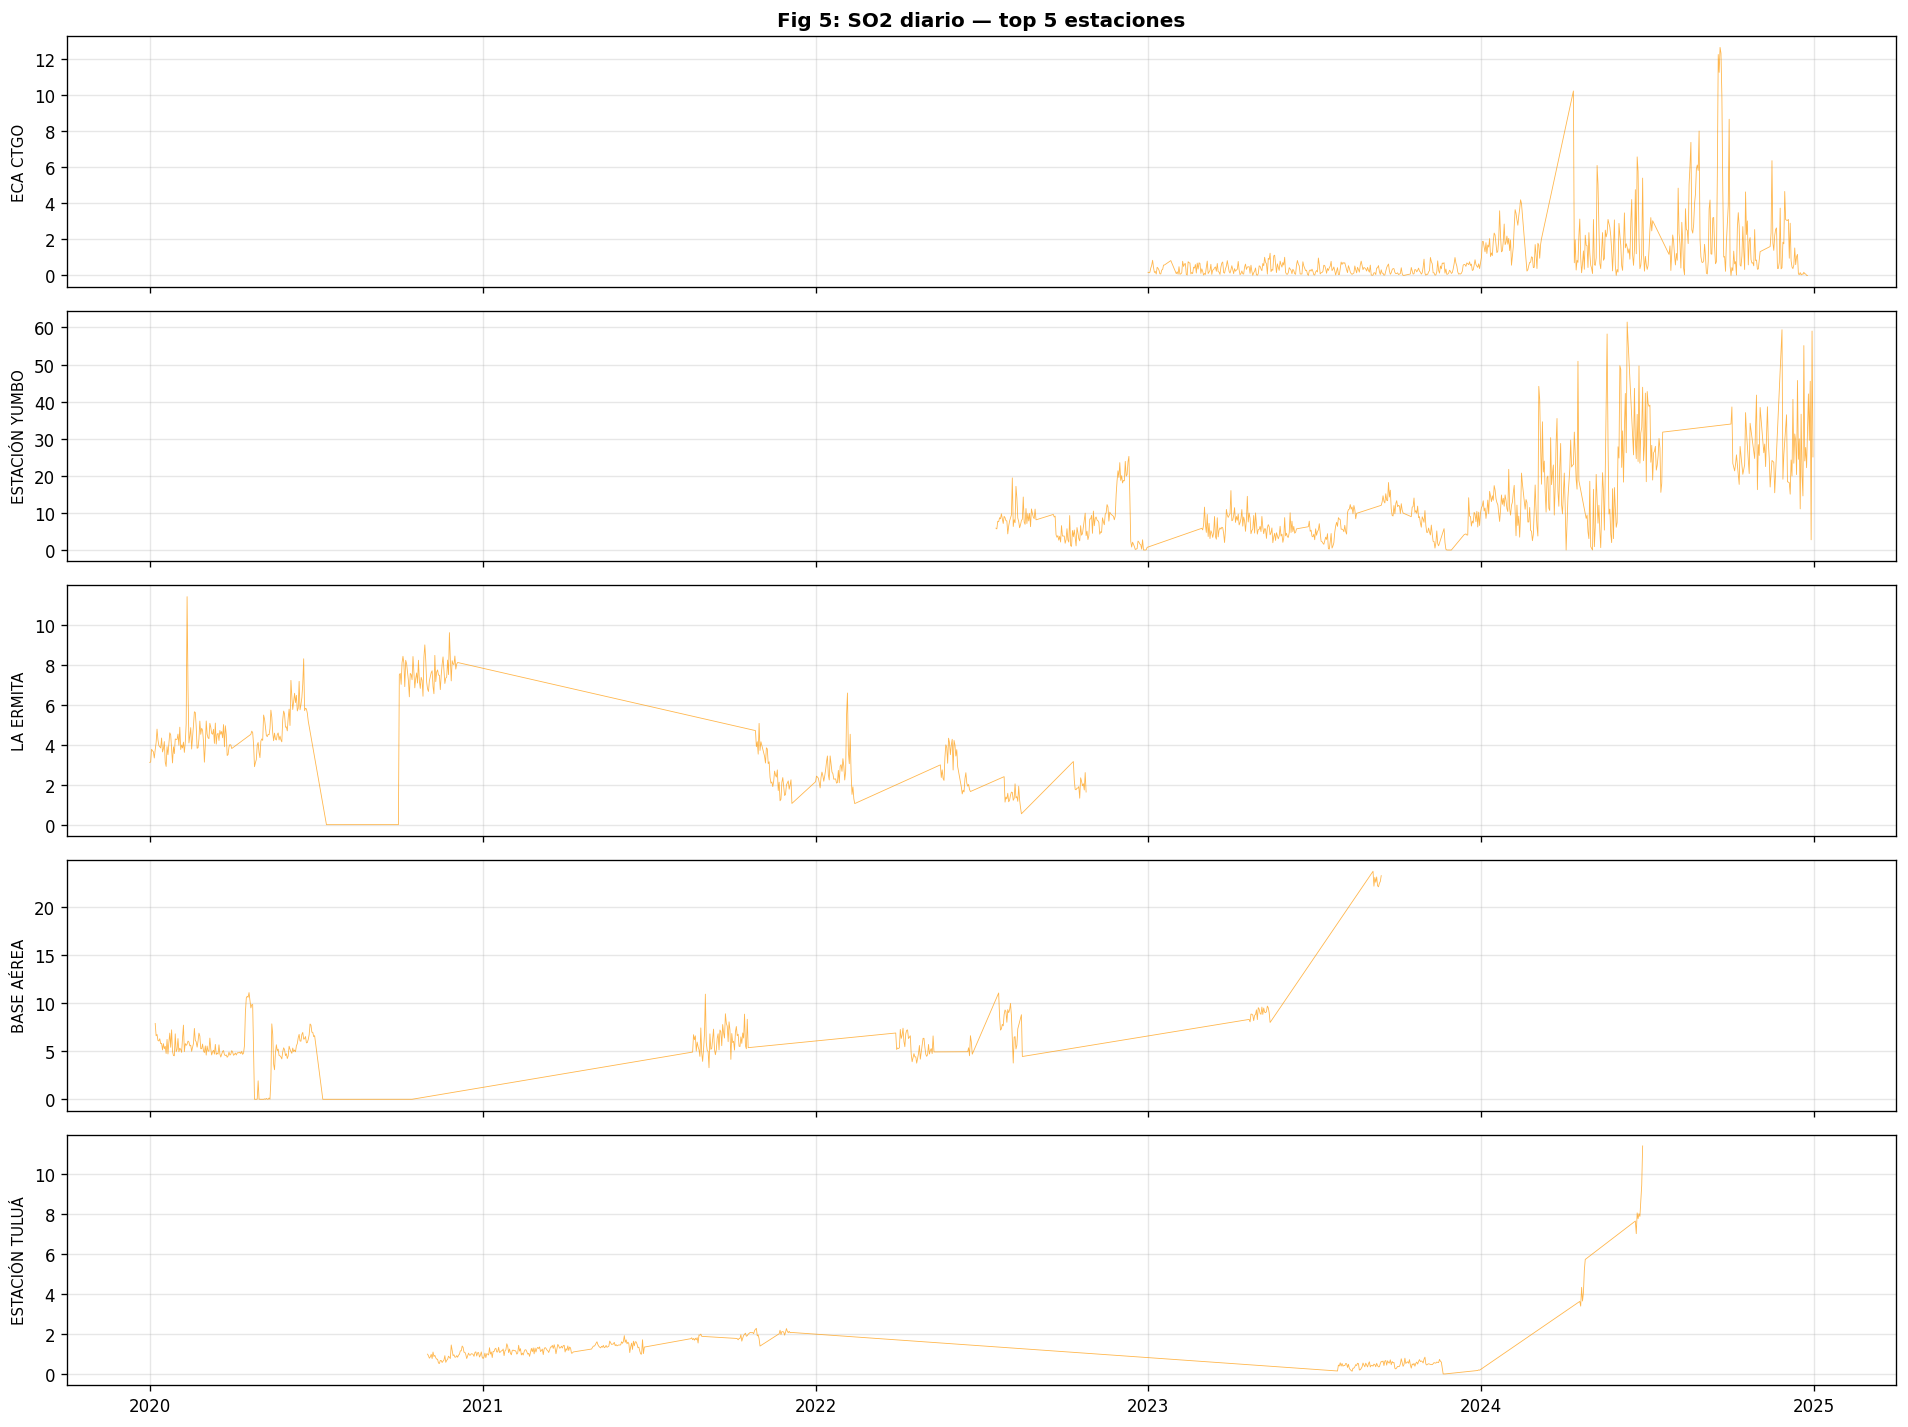

14679

In [14]:
if len(df_so2) > 1_000:
    df_so2["fecha_dia"] = df_so2["fecha"].dt.date
    ts_so2 = df_so2.groupby(["nombre_est", "fecha_dia"])["valor"].mean().reset_index()
    top5   = ts_so2.groupby("nombre_est").size().nlargest(5).index

    fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
    for ax, st in zip(axes, top5):
        d = ts_so2[ts_so2["nombre_est"] == st]
        ax.plot(pd.to_datetime(d["fecha_dia"]), d["valor"], lw=0.5, alpha=0.7, color="#FF9800")
        ax.set_ylabel(st, fontsize=9)
        ax.grid(alpha=0.3)
    axes[0].set_title("Fig 5: SO2 diario — top 5 estaciones", fontweight="bold")

    fig.tight_layout()
    plt.savefig(OUT_DIR / "05_so2_series_temporales.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()

gc.collect()

## Fig 6 · Series temporales O₃ (diario por estación)

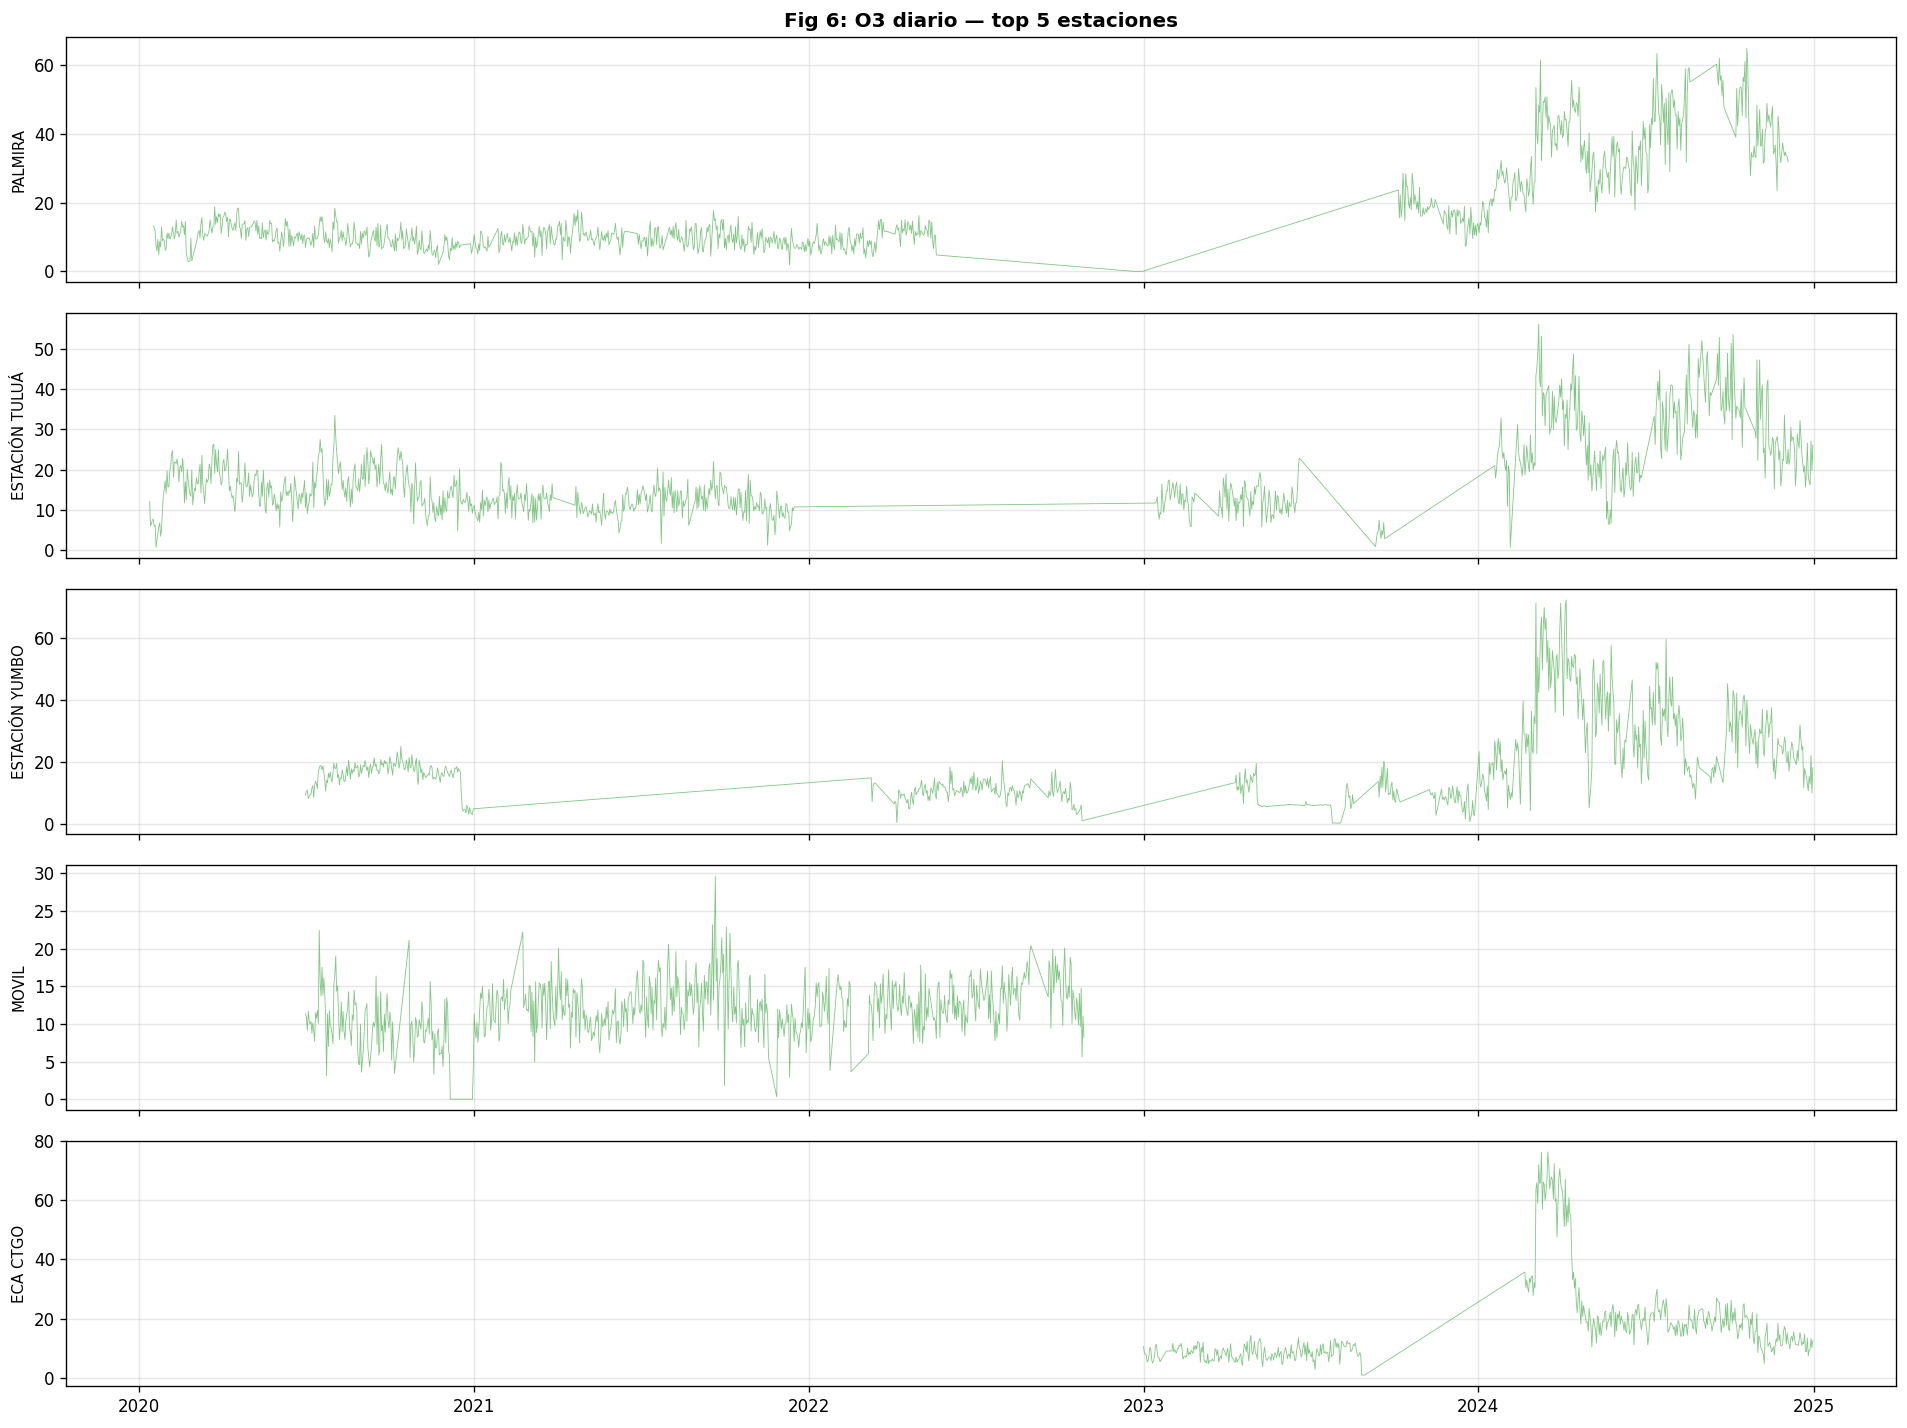

14307

In [15]:
if len(df_o3) > 1_000:
    df_o3["fecha_dia"] = df_o3["fecha"].dt.date
    ts_o3 = df_o3.groupby(["nombre_est", "fecha_dia"])["valor"].mean().reset_index()
    top5  = ts_o3.groupby("nombre_est").size().nlargest(5).index

    fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
    for ax, st in zip(axes, top5):
        d = ts_o3[ts_o3["nombre_est"] == st]
        ax.plot(pd.to_datetime(d["fecha_dia"]), d["valor"], lw=0.5, alpha=0.7, color="#4CAF50")
        ax.set_ylabel(st, fontsize=9)
        ax.grid(alpha=0.3)
    axes[0].set_title("Fig 6: O3 diario — top 5 estaciones", fontweight="bold")

    fig.tight_layout()
    plt.savefig(OUT_DIR / "06_o3_series_temporales.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()

gc.collect()

## Fig 7 · Ciclo diurno NO₂

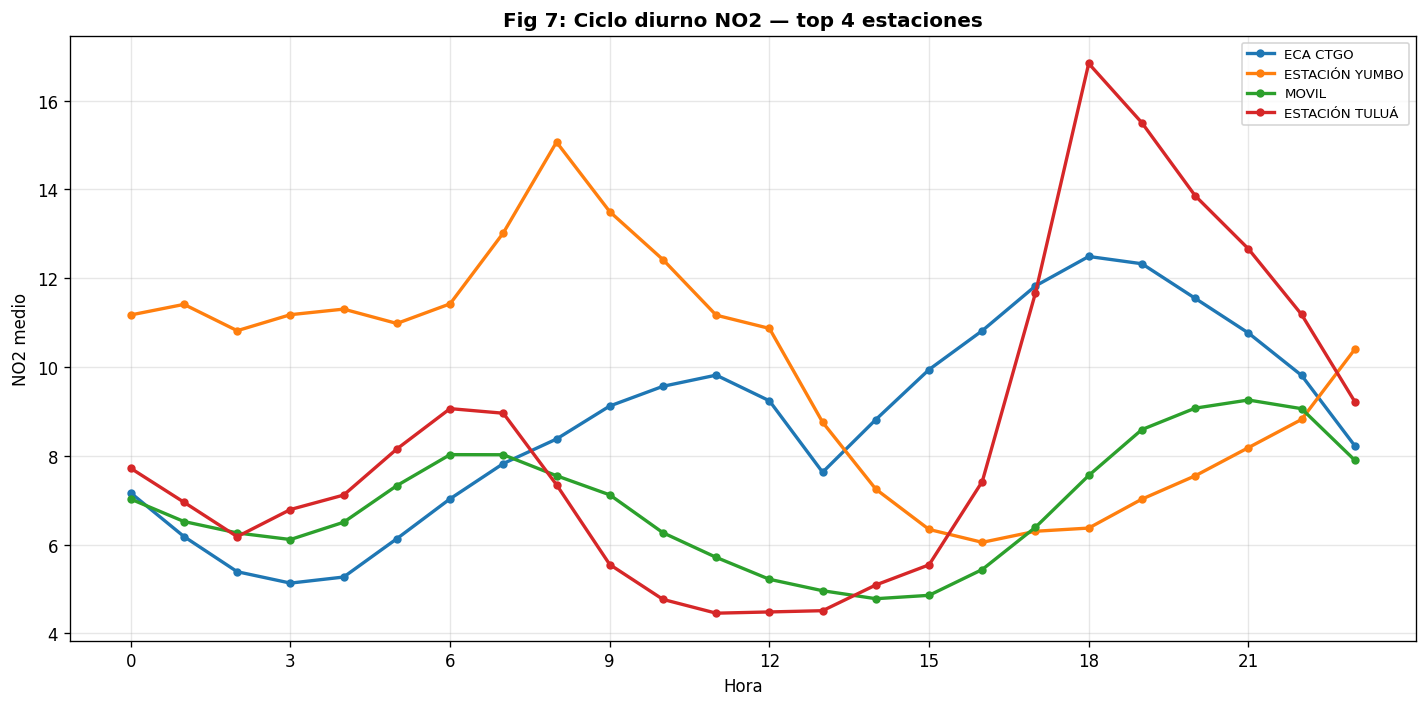

In [16]:
if len(df_no2) > 1_000:
    fig, ax = plt.subplots(figsize=(12, 6))
    for st in df_no2.groupby("nombre_est").size().nlargest(4).index:
        d = df_no2[df_no2["nombre_est"] == st].groupby("hora")["valor"].mean()
        ax.plot(d.index, d.values, "o-", lw=2, label=st, markersize=4)
    ax.set_xlabel("Hora")
    ax.set_ylabel("NO2 medio")
    ax.set_title("Fig 7: Ciclo diurno NO2 — top 4 estaciones", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(0, 24, 3))

    plt.tight_layout()
    plt.savefig(OUT_DIR / "07_no2_ciclo_diurno.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()

## Fig 8 · Ciclo diurno O₃

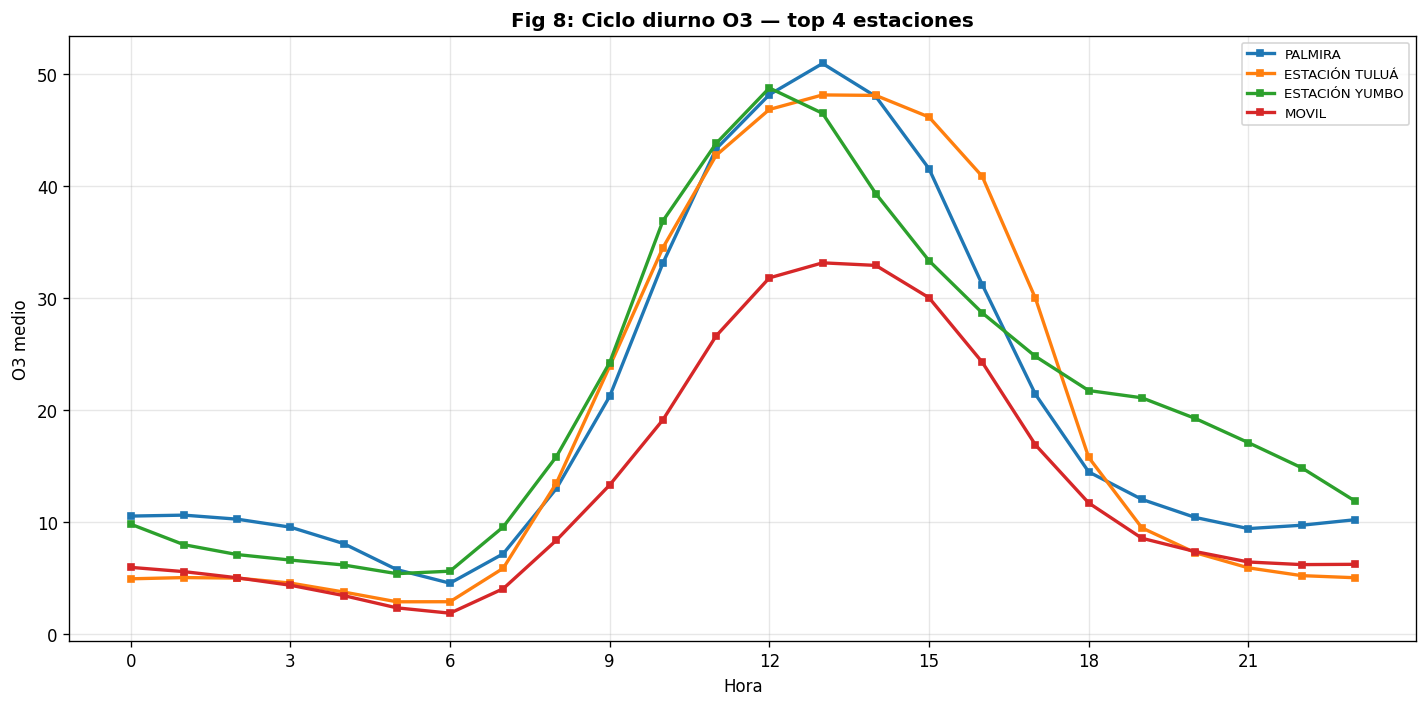

In [17]:
if len(df_o3) > 1_000:
    fig, ax = plt.subplots(figsize=(12, 6))
    for st in df_o3.groupby("nombre_est").size().nlargest(4).index:
        d = df_o3[df_o3["nombre_est"] == st].groupby("hora")["valor"].mean()
        ax.plot(d.index, d.values, "s-", lw=2, label=st, markersize=4)
    ax.set_xlabel("Hora")
    ax.set_ylabel("O3 medio")
    ax.set_title("Fig 8: Ciclo diurno O3 — top 4 estaciones", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(0, 24, 3))

    plt.tight_layout()
    plt.savefig(OUT_DIR / "08_o3_ciclo_diurno.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()

## Fig 9 · Mapa de estaciones DAGMA + CVC

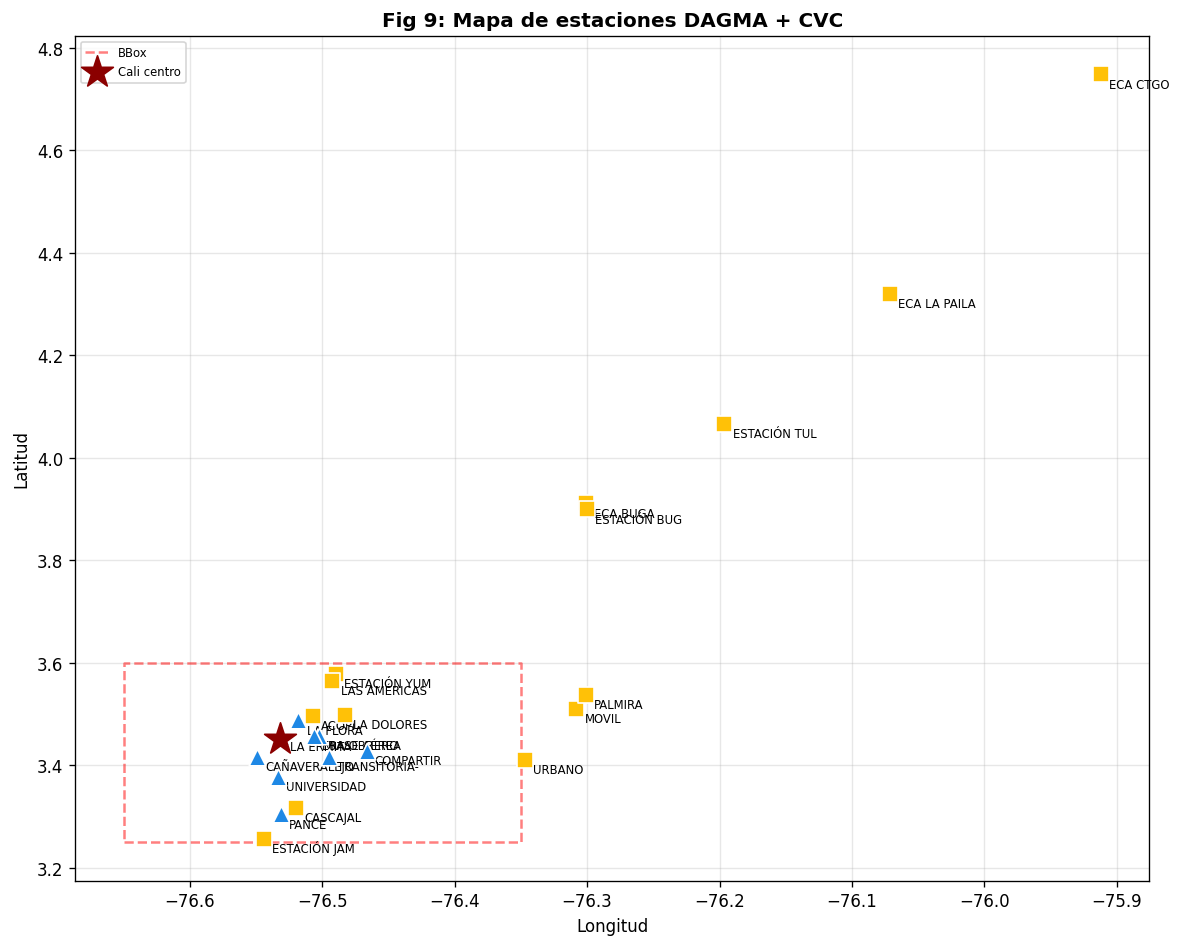

In [18]:
stations_loc = (
    df.groupby(["nombre_est", "nombre_fgda"])[["latitud", "longitud"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 8))
for _, r in stations_loc.iterrows():
    c = "#1E88E5" if r["nombre_fgda"] == "DAGMA" else "#FFC107"
    m = "^"       if r["nombre_fgda"] == "DAGMA" else "s"
    ax.scatter(r["longitud"], r["latitud"], c=c, s=100, marker=m,
               edgecolors="white", zorder=5)
    ax.annotate(r["nombre_est"][:12], (r["longitud"], r["latitud"]),
                textcoords="offset points", xytext=(5, -8), fontsize=7)

ax.plot([-76.65, -76.35, -76.35, -76.65, -76.65],
        [3.25,   3.25,   3.60,   3.60,   3.25],
        "r--", alpha=0.5, label="BBox")
ax.scatter(-76.532, 3.451, marker="*", s=400, color="darkred", zorder=10, label="Cali centro")

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(fontsize=7)
ax.set_title("Fig 9: Mapa de estaciones DAGMA + CVC", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "09_mapa_estaciones.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## Fig 10 · Boxplots estacionales SO₂

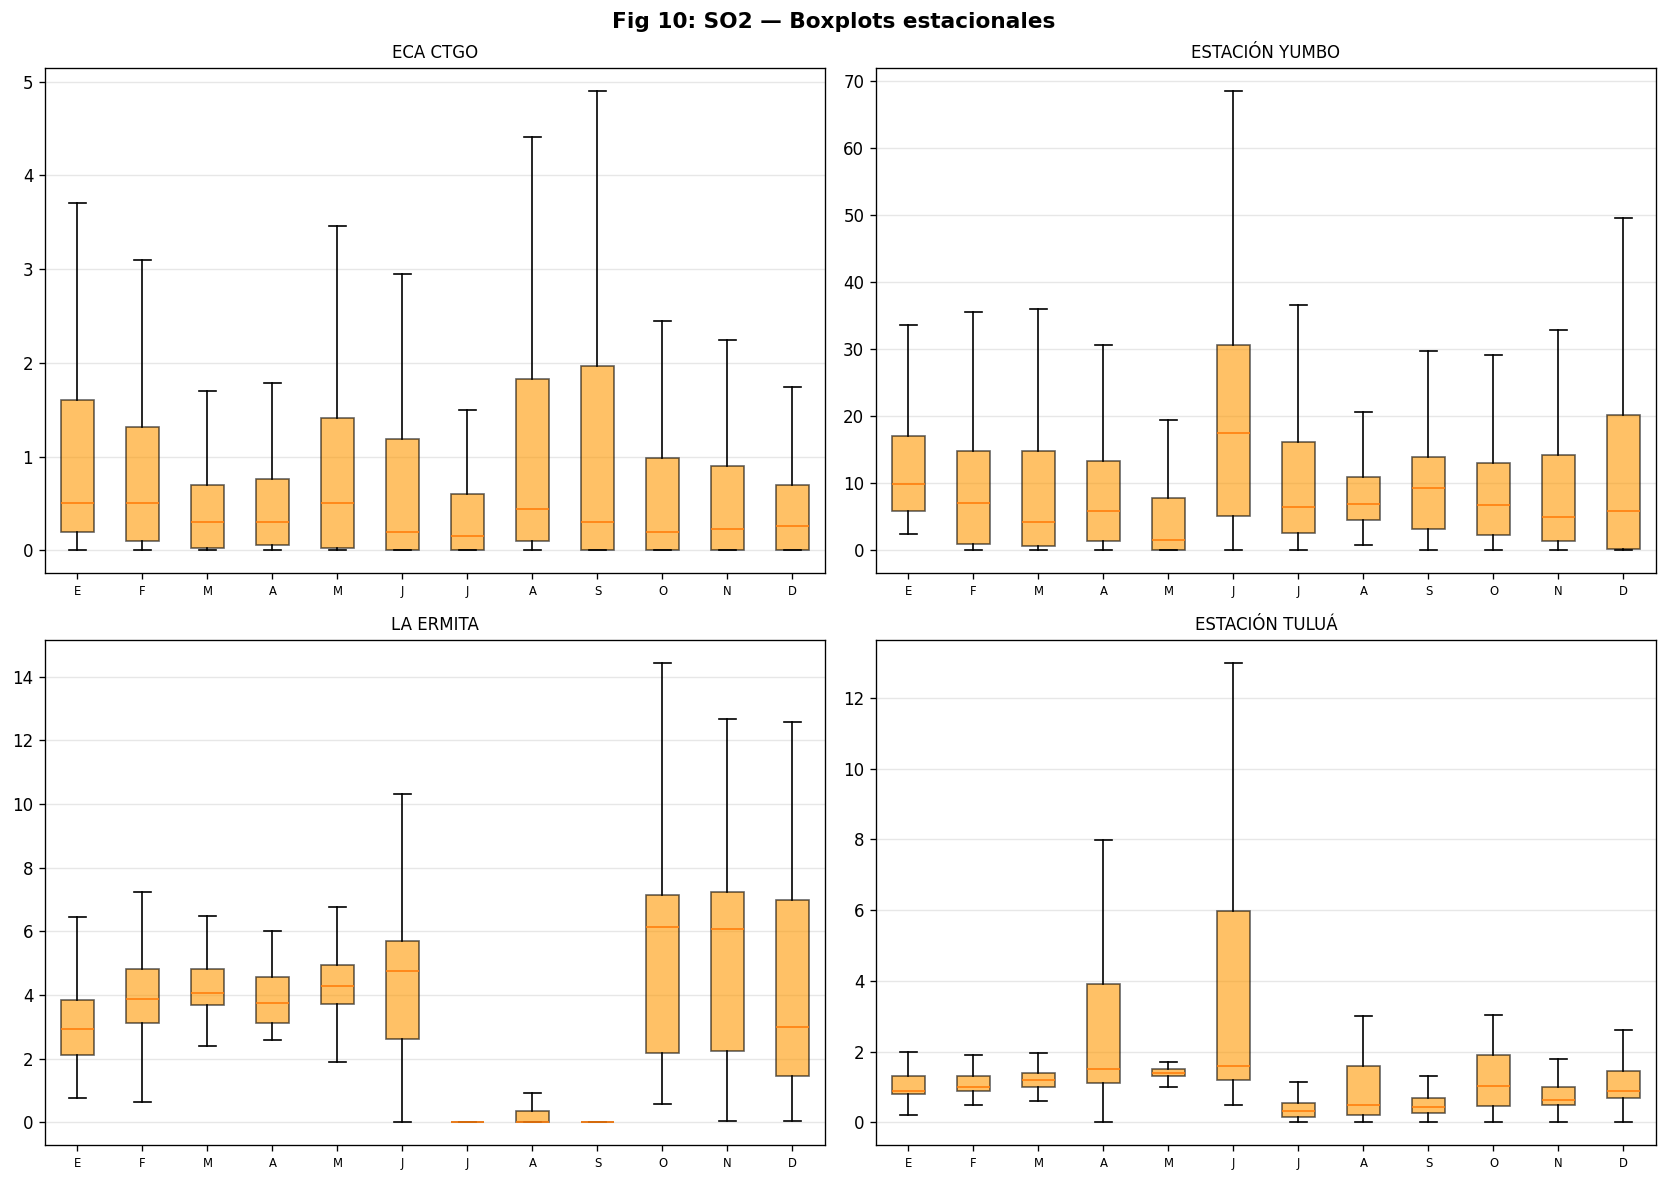

In [19]:
if len(df_so2) > 1_000:
    top4 = df_so2.groupby("nombre_est").size().nlargest(4).index
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, st in zip(axes.flat, top4):
        d    = df_so2[df_so2["nombre_est"] == st]
        data = [d[d["mes"] == m]["valor"].dropna().values for m in range(1, 13)]
        bp   = ax.boxplot(data, patch_artist=True, showfliers=False)
        for p in bp["boxes"]:
            p.set_facecolor("#FF9800")
            p.set_alpha(0.6)
        ax.set_title(st, fontsize=10)
        ax.set_xticklabels(["E","F","M","A","M","J","J","A","S","O","N","D"], fontsize=7)
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle("Fig 10: SO2 — Boxplots estacionales", fontweight="bold", fontsize=13)
    fig.tight_layout()
    plt.savefig(OUT_DIR / "10_so2_boxplots_mensuales.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()

## Fig 11 · Disponibilidad temporal NO₂ / SO₂ / O₃

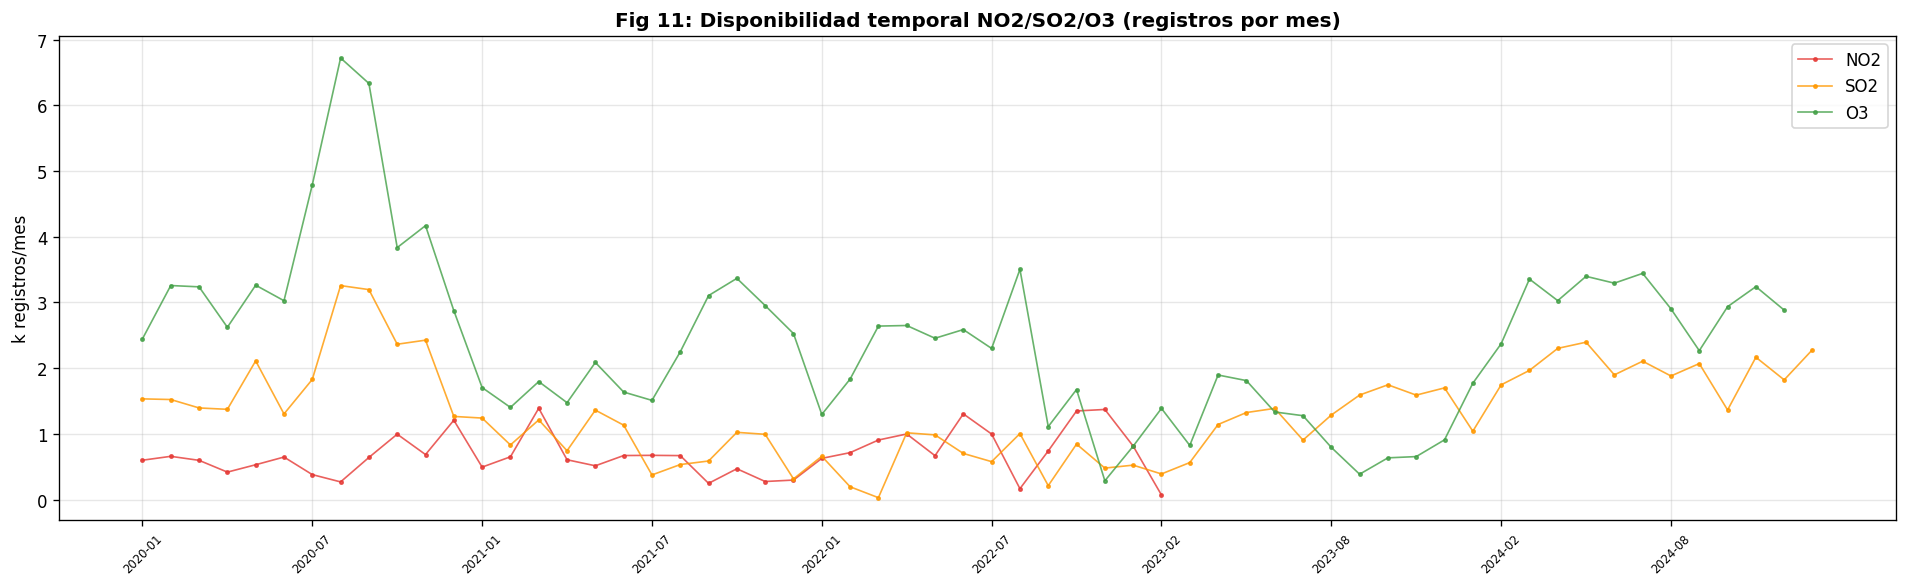

In [20]:
fig, ax = plt.subplots(figsize=(16, 5))

months = []
for i, target in enumerate(TARGETS):
    d = df[df["msfl_code"] == target]
    if len(d) < 100:
        continue
    monthly = d.groupby(d["fecha"].dt.to_period("M")).size()
    months  = [str(m) for m in monthly.index]
    ax.plot(range(len(months)), monthly.values / 1e3,
            "o-", lw=1, markersize=2,
            color=["#E53935","#FF9800","#43A047"][i],
            label=target, alpha=0.8)

if months:
    ax.set_xticks(range(0, len(months), 6))
    ax.set_xticklabels([months[i] for i in range(0, len(months), 6)], rotation=45, fontsize=7)

ax.set_ylabel("k registros/mes")
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Fig 11: Disponibilidad temporal NO2/SO2/O3 (registros por mes)", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR / "11_disponibilidad_temporal.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## Fig 12 · Correlación entre variables (3 estaciones top)

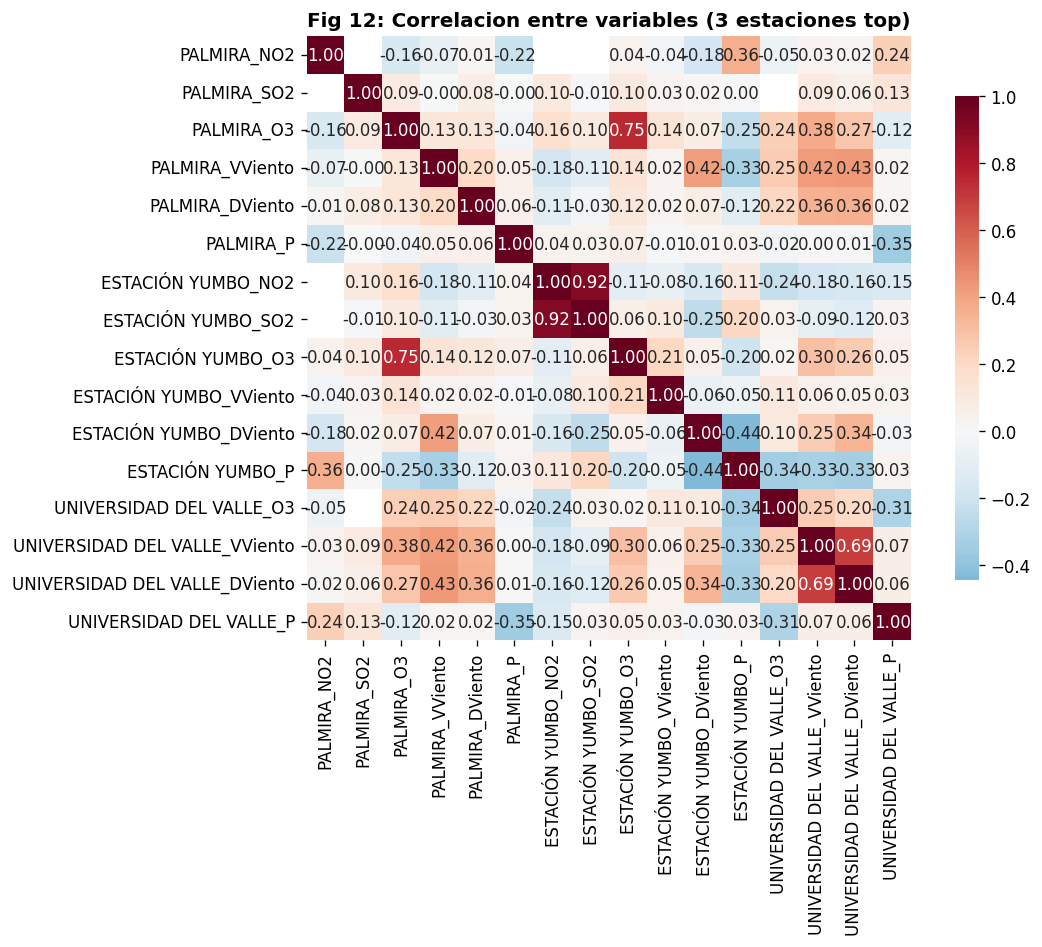

In [21]:
vars_corr  = TARGETS + METEOR + ["P"]
pivot_data = {}

for st in df.groupby("nombre_est").size().nlargest(3).index:
    d_st = df[(df["nombre_est"] == st) & (df["msfl_code"].isin(vars_corr))]
    for v in vars_corr:
        dv = d_st[d_st["msfl_code"] == v].groupby("fecha")["valor"].mean()
        if len(dv) > 100:
            pivot_data[f"{st}_{v}"] = dv

if len(pivot_data) >= 3:
    corr_df = pd.DataFrame(pivot_data).corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_df, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
                square=True, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title("Fig 12: Correlacion entre variables (3 estaciones top)", fontweight="bold")

    plt.tight_layout()
    plt.savefig(OUT_DIR / "12_correlacion_variables.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("No hay suficientes datos para calcular la correlacion.")

## Fig 13 · Completitud de datos (%) — top estaciones

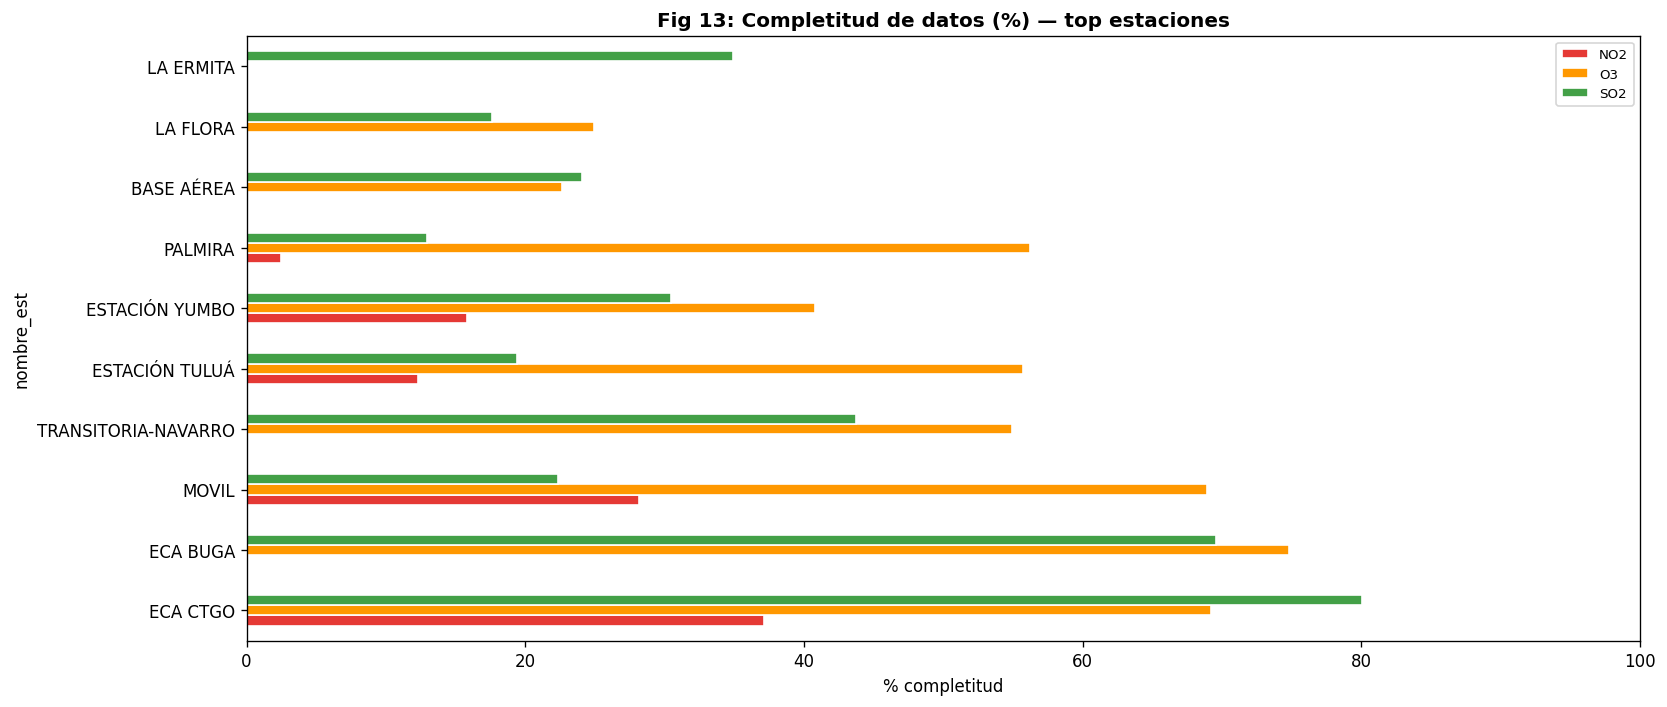

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

target_est = df[df["msfl_code"].isin(TARGETS)]
compl = (
    target_est.groupby(["nombre_est", "msfl_code"])
    .size()
    .unstack(fill_value=0)
    .astype(float)
)

max_hours = target_est.groupby("nombre_est")["fecha"].agg(
    lambda x: (x.max() - x.min()).total_seconds() / 3600 + 1
)

for st in compl.index:
    for v in TARGETS:
        if v in compl.columns:
            expected = max_hours.get(st, 1)
            compl.loc[st, v] = compl.loc[st, v] / expected * 100

compl = compl.clip(0, 100)
compl = compl.loc[compl.sum(axis=1).nlargest(10).index]
compl.plot(kind="barh", ax=ax,
           color=["#E53935", "#FF9800", "#43A047"],
           edgecolor="white")

ax.set_xlabel("% completitud")
ax.set_xlim(0, 100)
ax.set_title("Fig 13: Completitud de datos (%) — top estaciones", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "13_completitud.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## Resumen final

In [23]:
pngs = list(OUT_DIR.glob("*.png"))
print(f"EDA DAGMA completo → {OUT_DIR}")
print(f"   {len(pngs)} graficas guardadas en disco:")
for p in sorted(pngs):
    print(f"   · {p.name}")

EDA DAGMA completo → /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/dagma
   13 graficas guardadas en disco:
   · 01_registros_por_estacion.png
   · 02_variables_medidas.png
   · 03_heatmap_estacion_mes.png
   · 04_no2_series_temporales.png
   · 05_so2_series_temporales.png
   · 06_o3_series_temporales.png
   · 07_no2_ciclo_diurno.png
   · 08_o3_ciclo_diurno.png
   · 09_mapa_estaciones.png
   · 10_so2_boxplots_mensuales.png
   · 11_disponibilidad_temporal.png
   · 12_correlacion_variables.png
   · 13_completitud.png
